Dataset có 10,345 dòng và 20 cột

Các cột trong dữ liệu:
['job_id', 'job_title', 'company_size', 'company_industry', 'country', 'remote_type', 'experience_level', 'years_experience', 'education_level', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month', 'job_posting_year', 'hiring_urgency', 'job_openings', 'job_posting_date']


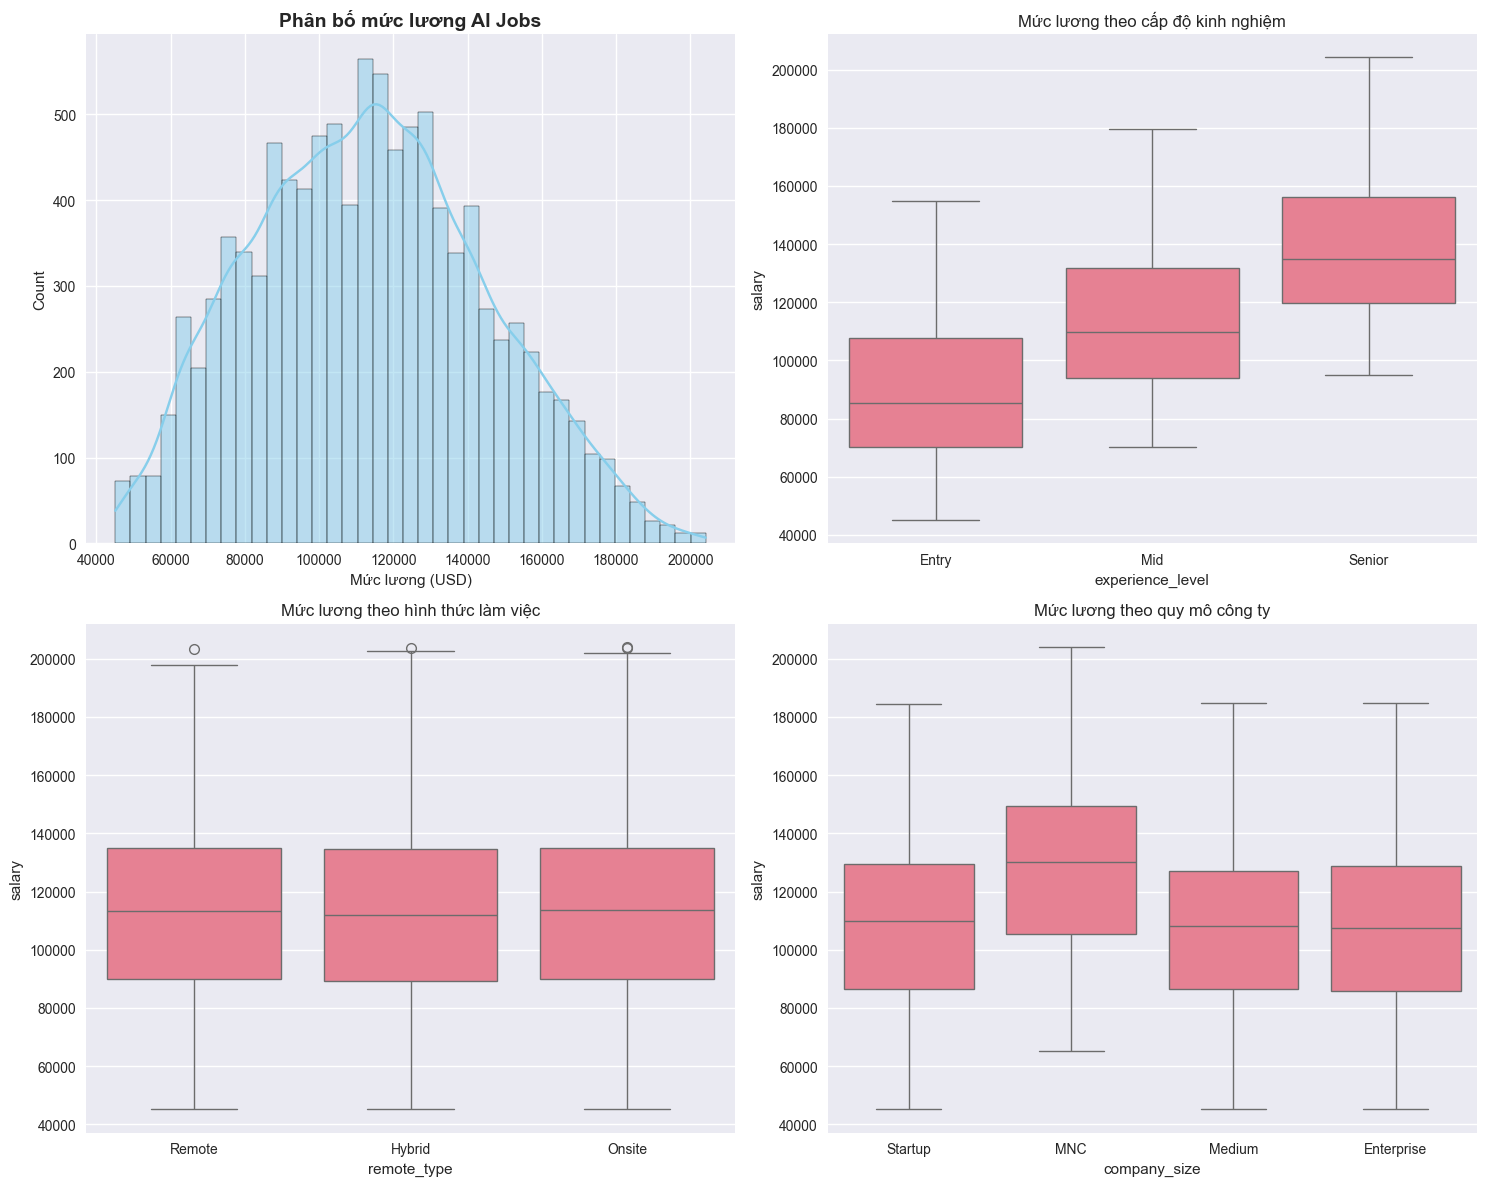

C:\Users\Admin\AppData\Local\Temp\ipykernel_3296\759713150.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_3296\759713150.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, ax=axes[1], palette='mako')


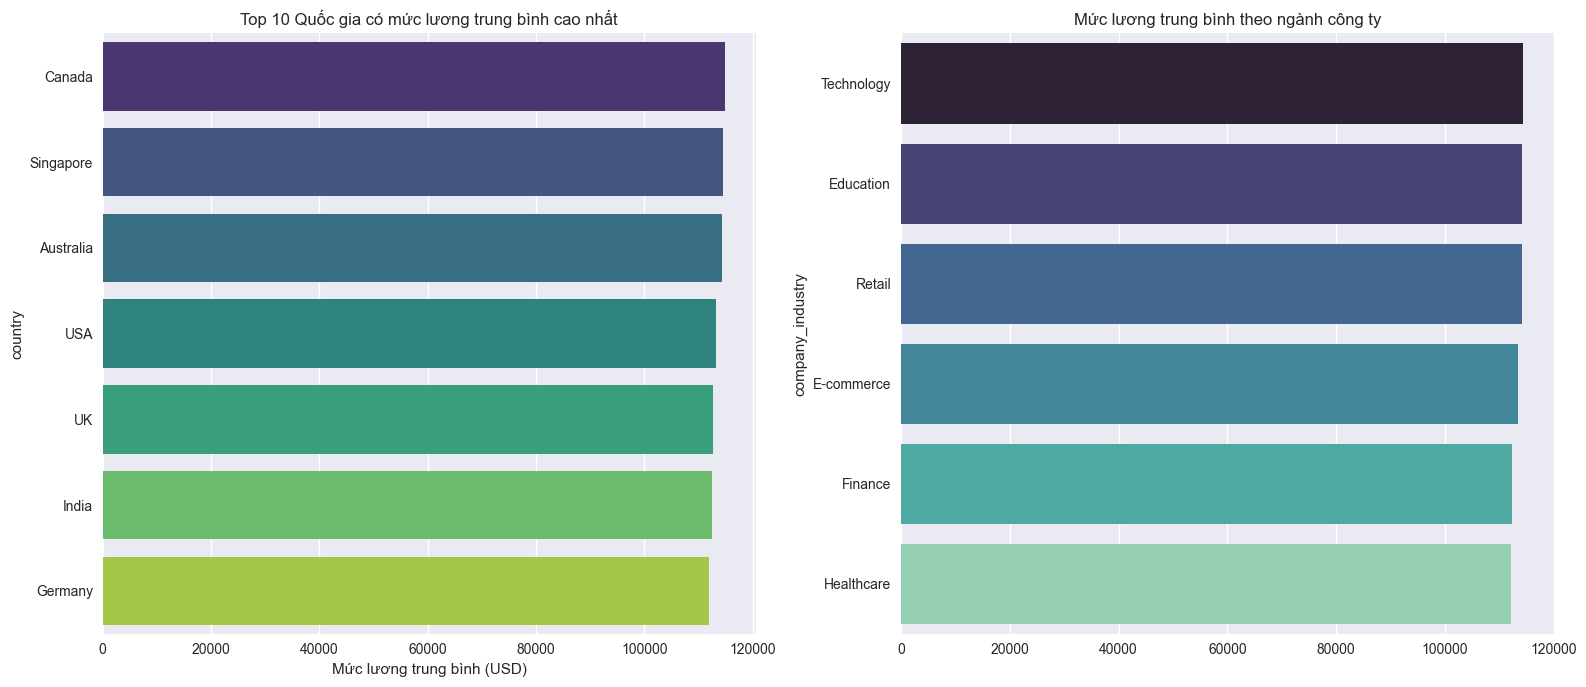

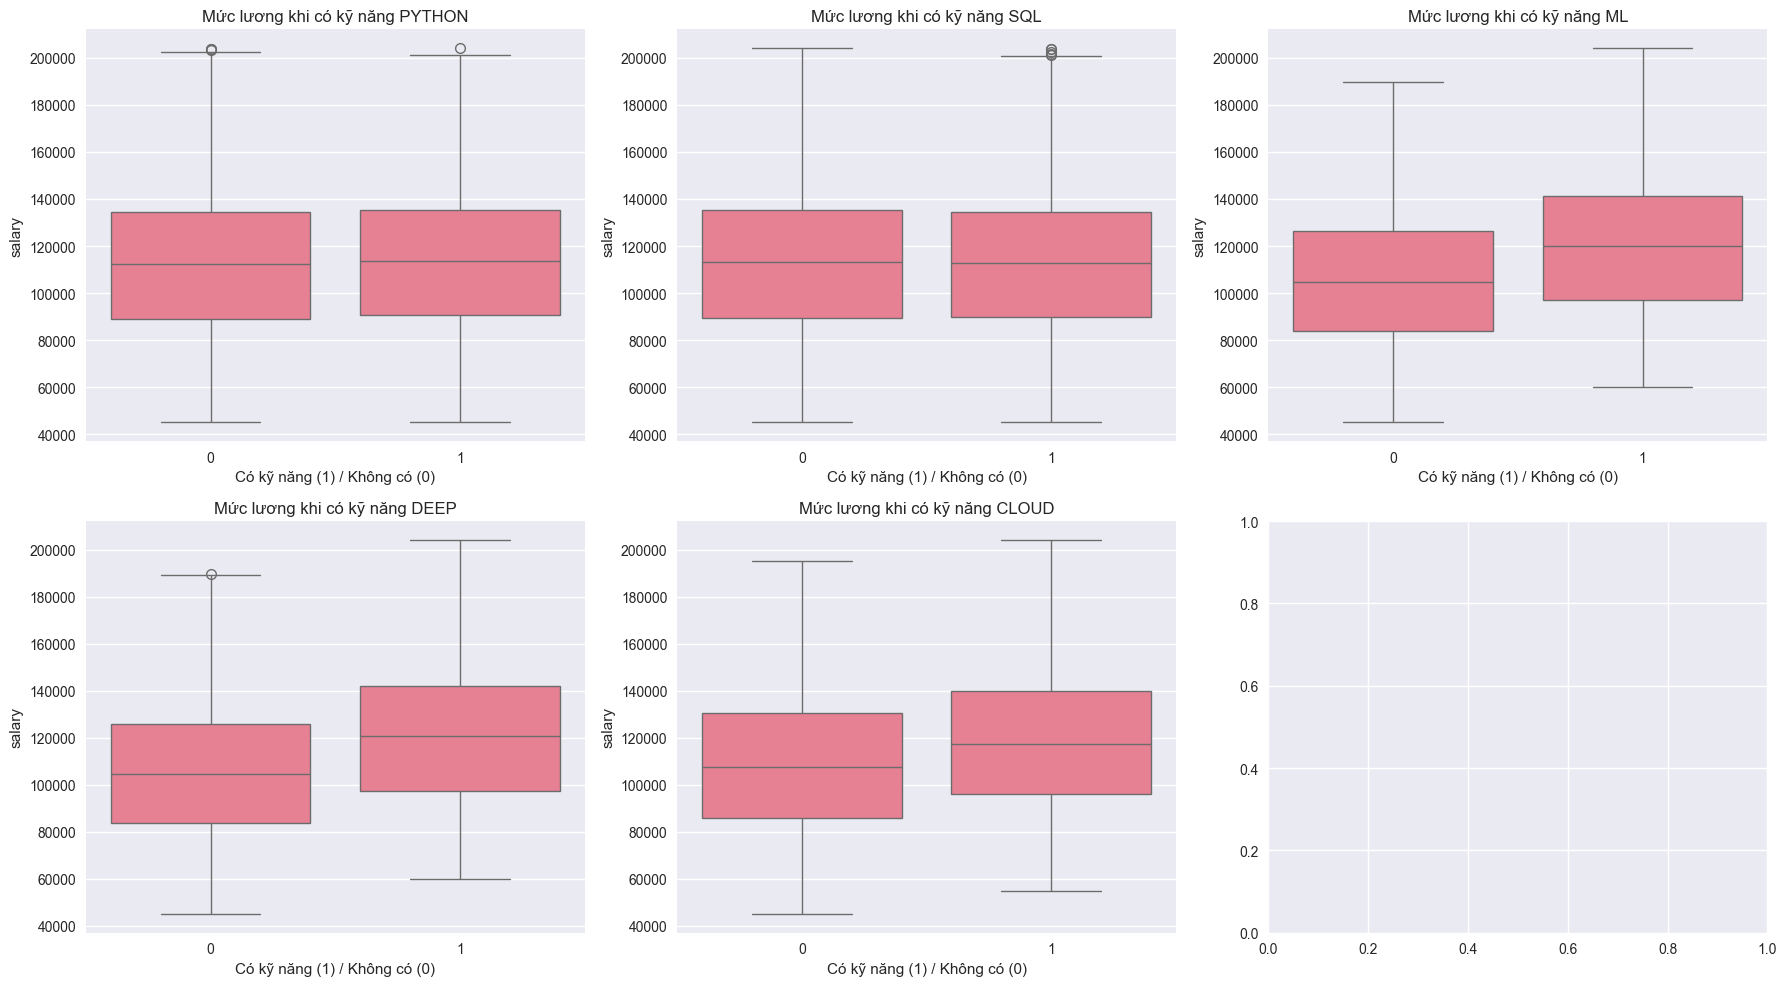

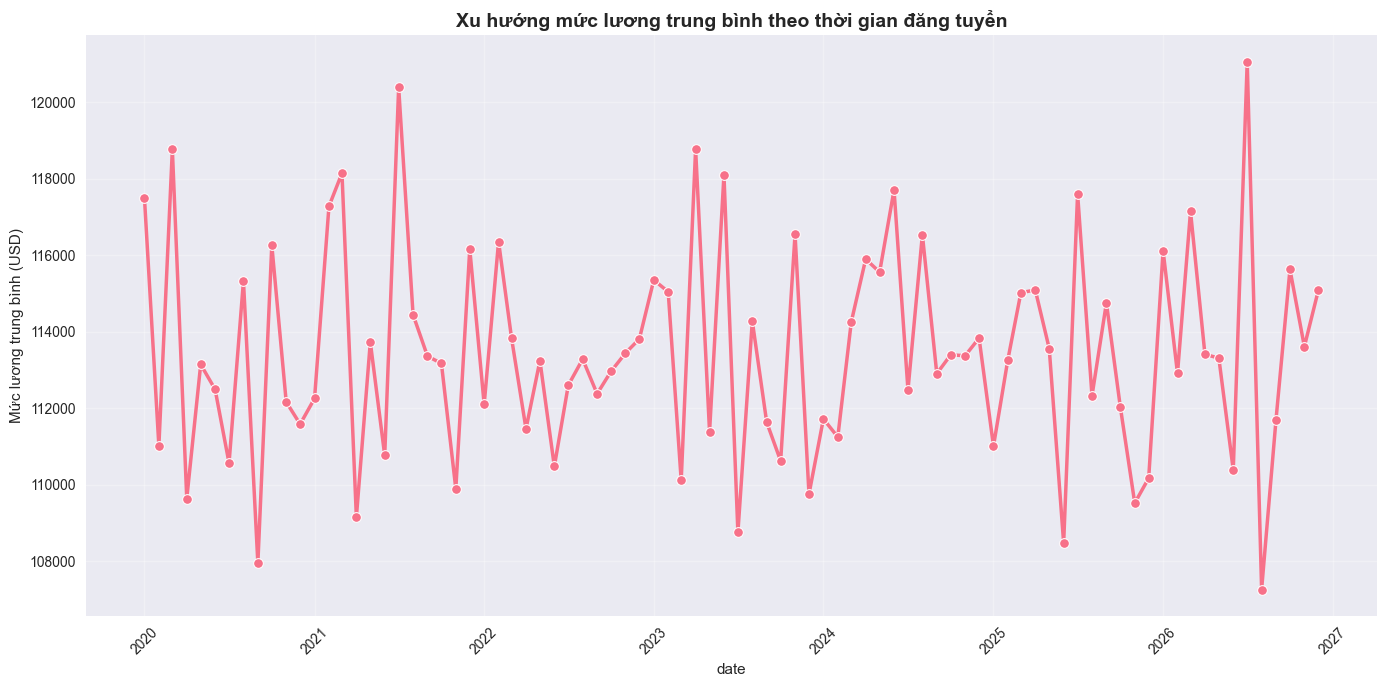

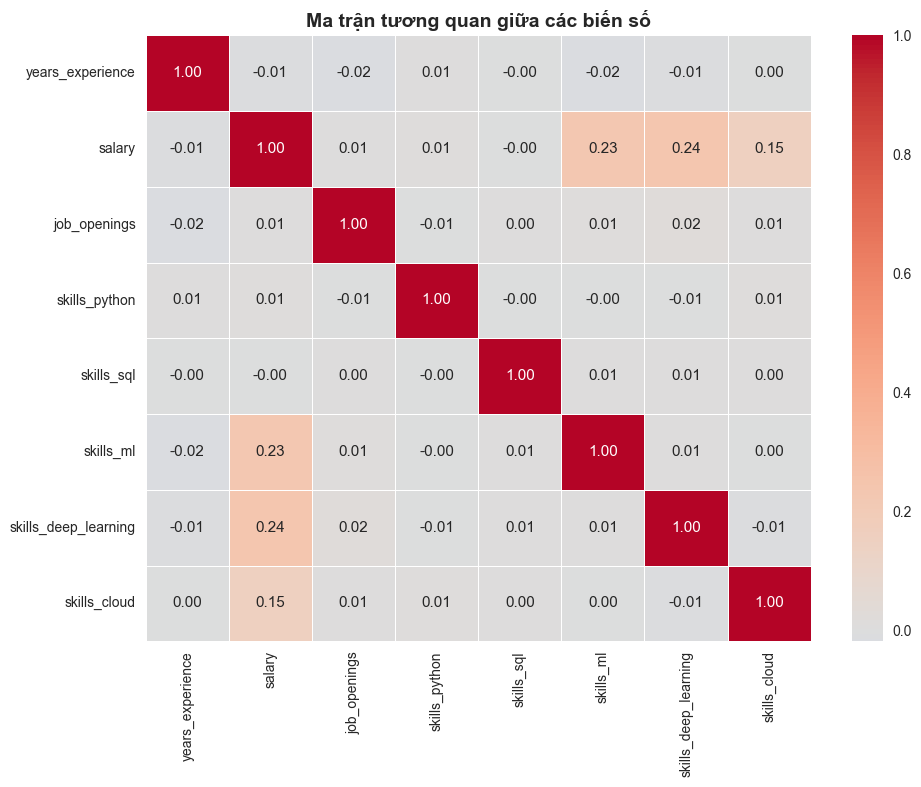


THỐNG KÊ TÓM TẮT DỮ LIỆU AI JOB MARKET

Tổng số việc làm: 10,345
Mức lương trung bình: $113,438
Mức lương cao nhất: $204,143
Mức lương thấp nhất: $45,083

Top 5 nghề có nhiều việc làm nhất:
job_title
Business Analyst             1773
AI Engineer                  1742
Machine Learning Engineer    1740
Data Analyst                 1711
Data Scientist               1703
Name: count, dtype: int64

Tỷ lệ Remote/Hybrid/Onsite:
remote_type
Remote    34.0
Hybrid    33.1
Onsite    33.0
Name: proportion, dtype: float64

Tỷ lệ theo cấp độ kinh nghiệm:
experience_level
Entry     34.0
Senior    33.1
Mid       33.0
Name: proportion, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# ====================== CÀI ĐẶT GIAO DIỆN ======================
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# ====================== ĐỌC DỮ LIỆU ======================
df = pd.read_csv('AI Job Market Dataset.csv')

# Chuyển đổi kiểu dữ liệu nếu cần
df['job_posting_date'] = pd.to_datetime(df['job_posting_year'].astype(str) + '-' + 
                                       df['job_posting_month'].astype(str) + '-01')

print(f"Dataset có {df.shape[0]:,} dòng và {df.shape[1]} cột")
print("\nCác cột trong dữ liệu:")
print(df.columns.tolist())

# ====================== 1. PHÂN BỐ MỨC LƯƠNG ======================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram lương
sns.histplot(data=df, x='salary', kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Phân bố mức lương AI Jobs', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Mức lương (USD)')

# Boxplot lương theo experience_level
sns.boxplot(data=df, x='experience_level', y='salary', ax=axes[0,1], order=['Entry', 'Mid', 'Senior'])
axes[0,1].set_title('Mức lương theo cấp độ kinh nghiệm')

# Boxplot lương theo remote_type
sns.boxplot(data=df, x='remote_type', y='salary', ax=axes[1,0])
axes[1,0].set_title('Mức lương theo hình thức làm việc')

# Boxplot lương theo company_size
sns.boxplot(data=df, x='company_size', y='salary', ax=axes[1,1])
axes[1,1].set_title('Mức lương theo quy mô công ty')

plt.tight_layout()
plt.show()

# ====================== 2. LƯƠNG THEO QUỐC GIA & NGÀNH ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 quốc gia có mức lương cao nhất
top_countries = df.groupby('country')['salary'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Quốc gia có mức lương trung bình cao nhất')
axes[0].set_xlabel('Mức lương trung bình (USD)')

# Lương theo ngành nghề
top_industries = df.groupby('company_industry')['salary'].mean().sort_values(ascending=False)
sns.barplot(x=top_industries.values, y=top_industries.index, ax=axes[1], palette='mako')
axes[1].set_title('Mức lương trung bình theo ngành công ty')

plt.tight_layout()
plt.show()

# ====================== 3. KỸ NĂNG & LƯƠNG ======================
skills = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, skill in enumerate(skills):
    sns.boxplot(data=df, x=skill, y='salary', ax=axes[i])
    axes[i].set_title(f'Mức lương khi có kỹ năng {skill.split("_")[1].upper()}')
    axes[i].set_xlabel('Có kỹ năng (1) / Không có (0)')

plt.tight_layout()
plt.show()

# ====================== 4. XU HƯỚNG THEO THỜI GIAN ======================
monthly_salary = df.groupby(['job_posting_year', 'job_posting_month'])['salary'].agg(['mean', 'count']).reset_index()
monthly_salary['date'] = pd.to_datetime(monthly_salary['job_posting_year'].astype(str) + '-' + 
                                      monthly_salary['job_posting_month'].astype(str) + '-01')

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_salary, x='date', y='mean', marker='o', linewidth=2.5)
plt.title('Xu hướng mức lương trung bình theo thời gian đăng tuyển', fontsize=14, fontweight='bold')
plt.ylabel('Mức lương trung bình (USD)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ====================== 5. HEATMAP TƯƠNG QUAN ======================
plt.figure(figsize=(10, 8))
numeric_cols = ['years_experience', 'salary', 'job_openings'] + skills
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ====================== 6. THỐNG KÊ TÓM TẮT ======================
print("\n" + "="*60)
print("THỐNG KÊ TÓM TẮT DỮ LIỆU AI JOB MARKET")
print("="*60)

print(f"\nTổng số việc làm: {len(df):,}")
print(f"Mức lương trung bình: ${df['salary'].mean():,.0f}")
print(f"Mức lương cao nhất: ${df['salary'].max():,.0f}")
print(f"Mức lương thấp nhất: ${df['salary'].min():,.0f}")

print(f"\nTop 5 nghề có nhiều việc làm nhất:")
print(df['job_title'].value_counts().head(5))

print(f"\nTỷ lệ Remote/Hybrid/Onsite:")
print(df['remote_type'].value_counts(normalize=True).round(3)*100)

print(f"\nTỷ lệ theo cấp độ kinh nghiệm:")
print(df['experience_level'].value_counts(normalize=True).round(3)*100)

# ====================== LƯU CÁC BIỂU ĐỒ (tùy chọn) ======================
# Uncomment nếu bạn muốn lưu file
# plt.savefig('ai_job_salary_analysis.png', dpi=300, bbox_inches='tight')